SECTOR BEHAVIORAL CORRELATION PLOTTER
Loading data...
✓ Loaded 1235 behavioral connections
✓ Loaded 2132640 data records

📈 Plotting correlations for: KJ0016A

🔍 Finding sectors correlated with 'KJ0016A'...
✓ Found 95 correlated sectors


C:\Users\USER\AppData\Local\Temp\ipykernel_19580\2188666772.py:252: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_19580\2188666772.py:252: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_19580\2188666772.py:256: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\USER\AppData\Local\Temp\ipykernel_19580\2188666772.py:256: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')


✓ Plot saved to anomaly_results_pic\correlation_plot_KJ0016A.png


c:\Users\USER\anaconda3\envs\geo_anom\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\anaconda3\envs\geo_anom\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


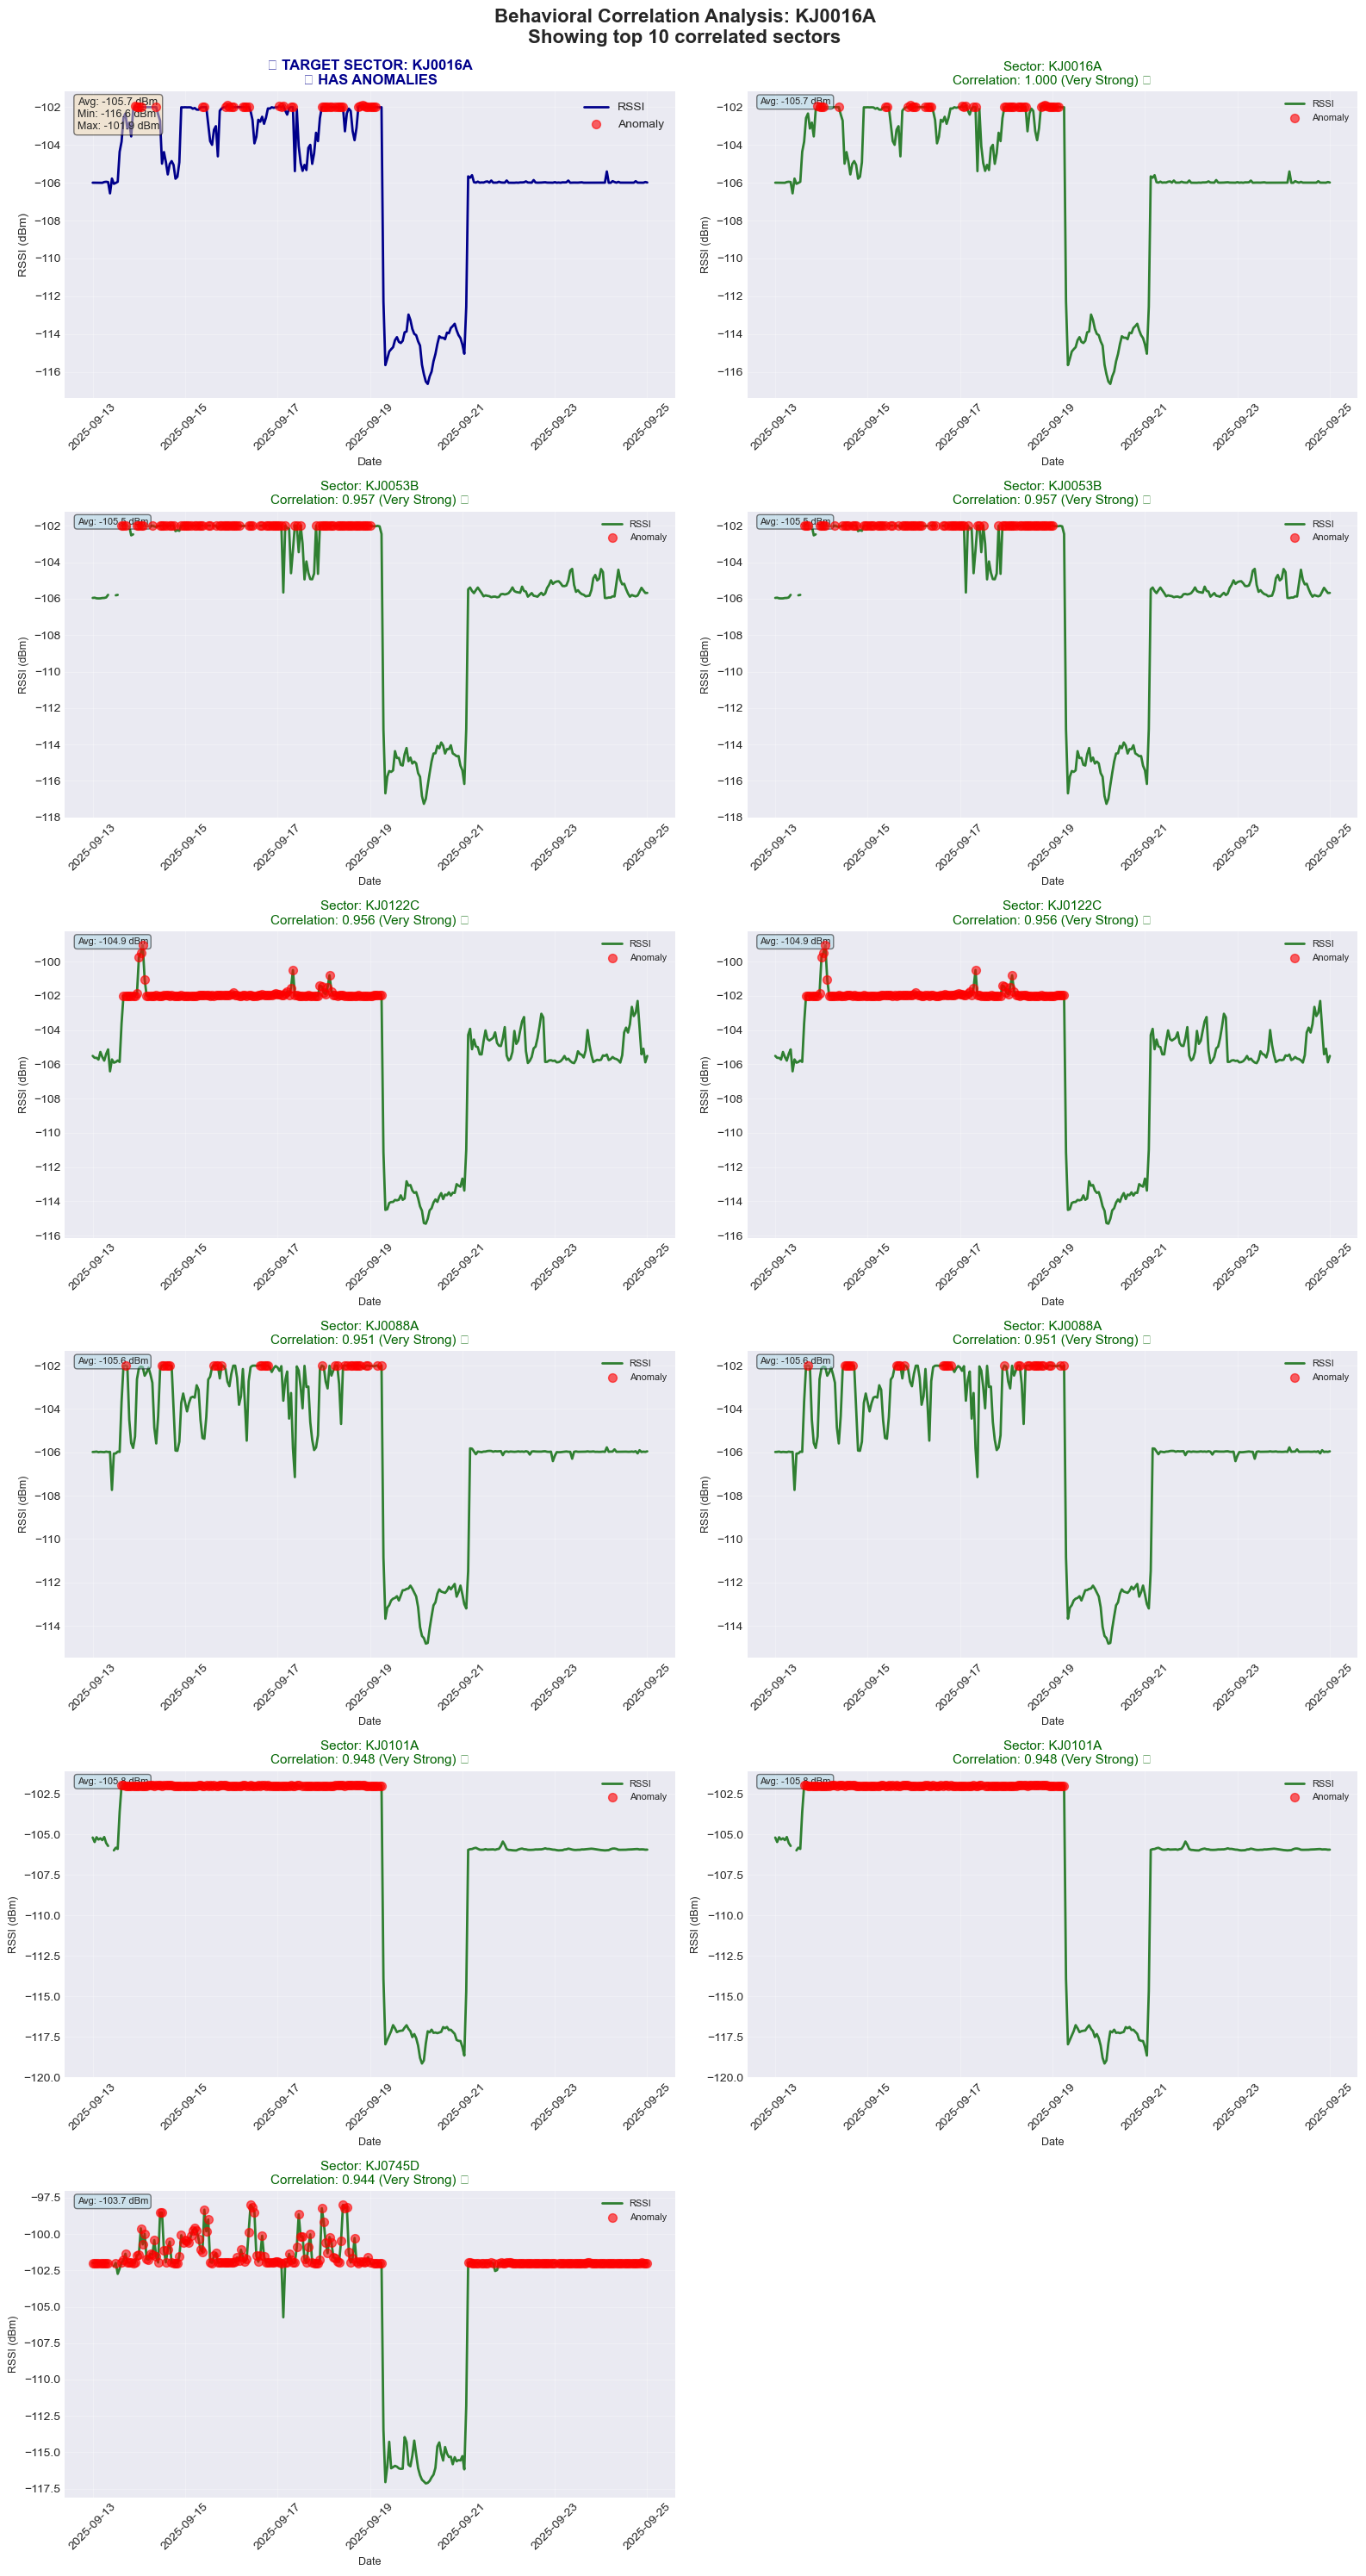


CORRELATION SUMMARY FOR: KJ0016A
  KJ0016A         | Corr: 1.000 | Avg RSSI: -108.0 dBm | ⚠ ANOMALY
  KJ0053B         | Corr: 0.957 | Avg RSSI: -107.8 dBm | ⚠ ANOMALY
  KJ0053B         | Corr: 0.957 | Avg RSSI: -107.8 dBm | ⚠ ANOMALY
  KJ0122C         | Corr: 0.956 | Avg RSSI: -107.2 dBm | ⚠ ANOMALY
  KJ0122C         | Corr: 0.956 | Avg RSSI: -107.2 dBm | ⚠ ANOMALY
  KJ0088A         | Corr: 0.951 | Avg RSSI: -107.9 dBm | ⚠ ANOMALY
  KJ0088A         | Corr: 0.951 | Avg RSSI: -107.9 dBm | ⚠ ANOMALY
  KJ0101A         | Corr: 0.948 | Avg RSSI: -108.2 dBm | ⚠ ANOMALY
  KJ0101A         | Corr: 0.948 | Avg RSSI: -108.2 dBm | ⚠ ANOMALY
  KJ0745D         | Corr: 0.944 | Avg RSSI: -106.4 dBm | ⚠ ANOMALY


In [7]:
#!/usr/bin/env python3
"""
Plot RSSI time series for a sector and all its behaviorally correlated neighbors.
Uses behavioral_connections.csv to find correlated sectors.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class SectorCorrelationPlotter:
    """Plot RSSI correlations for sectors"""
    
    def __init__(self, data_file, connections_file, results_dir='anomaly_results'):
        """
        Initialize the plotter
        
        Args:
            data_file: Path to main data CSV (with RSSI values)
            connections_file: Path to behavioral_connections.csv
            results_dir: Directory containing analysis results
        """
        self.data_file = data_file
        self.connections_file = connections_file
        self.results_dir = Path(results_dir)
        
        # Load data
        print("Loading data...")
        self.data_df = pd.read_csv(data_file)
        self.data_df['Date'] = pd.to_datetime(self.data_df['Date'])
        
        # Load behavioral connections
        connections_path = self.results_dir / connections_file
        if not connections_path.exists():
            print(f"❌ Error: {connections_path} not found!")
            print("Please run the analysis first to generate behavioral_connections.csv")
            sys.exit(1)
            
        self.connections_df = pd.read_csv(connections_path)
        print(f"✓ Loaded {len(self.connections_df)} behavioral connections")
        print(f"✓ Loaded {len(self.data_df)} data records")
        
    def find_correlated_sectors(self, sector_name):
        """
        Find all sectors correlated with the given sector
        
        Args:
            sector_name: Name of the sector to query
            
        Returns:
            DataFrame with correlated sectors and their info
        """
        # Find connections where sector is either sector_1 or sector_2
        connections = self.connections_df[
            (self.connections_df['sector_1'] == sector_name) | 
            (self.connections_df['sector_2'] == sector_name)
        ].copy()
        
        if len(connections) == 0:
            return None
        
        # Create a list of correlated sectors
        correlated = []
        for _, row in connections.iterrows():
            if row['sector_1'] == sector_name:
                correlated.append({
                    'sector': row['sector_2'],
                    'correlation': row['correlation'],
                    'has_anomaly': row['sector_2_has_anomaly'],
                    'avg_rssi': row['sector_2_avg_rssi']
                })
            else:
                correlated.append({
                    'sector': row['sector_1'],
                    'correlation': row['correlation'],
                    'has_anomaly': row['sector_1_has_anomaly'],
                    'avg_rssi': row['sector_1_avg_rssi']
                })
        
        return pd.DataFrame(correlated).sort_values('correlation', ascending=False)
    
    def plot_sector_and_correlations(self, sector_name, date_range=None, top_n=10, save_path=None):
        """
        Plot RSSI time series for a sector and its correlated neighbors
        
        Args:
            sector_name: Name of the sector to plot
            date_range: Tuple of (start_date, end_date) or None for all dates
            top_n: Number of top correlated sectors to show (default: 10)
            save_path: Path to save the plot (optional)
        """
        # Check if sector exists in data
        if sector_name not in self.data_df['NE'].values:
            print(f"❌ Error: Sector '{sector_name}' not found in data!")
            available_sectors = self.data_df['NE'].unique()[:20]
            print(f"Available sectors (first 20): {', '.join(available_sectors)}")
            return
        
        # Find correlated sectors
        print(f"\n🔍 Finding sectors correlated with '{sector_name}'...")
        correlated_df = self.find_correlated_sectors(sector_name)
        
        if correlated_df is None or len(correlated_df) == 0:
            print(f"⚠ No correlated sectors found for '{sector_name}'")
            print("This sector may not have strong behavioral connections (correlation > 0.7)")
            return
        
        print(f"✓ Found {len(correlated_df)} correlated sectors")
        
        # Limit to top N
        correlated_df = correlated_df.head(top_n)
        
        # Get RSSI data for main sector
        sector_data = self.data_df[self.data_df['NE'] == sector_name].copy()
        
        # Filter by date range if provided
        if date_range:
            start_date, end_date = date_range
            sector_data = sector_data[
                (sector_data['Date'] >= start_date) & 
                (sector_data['Date'] <= end_date)
            ]
        
        sector_data = sector_data.sort_values('Date')
        
        # Create figure with subplots
        n_plots = len(correlated_df) + 1  # +1 for main sector
        n_cols = min(2, n_plots)
        n_rows = (n_plots + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
        if n_plots == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        # Plot main sector (first plot)
        ax = axes[0]
        has_anomaly = sector_data['Anomaly'].any() if 'Anomaly' in sector_data.columns else False
        
        # Plot RSSI
        ax.plot(sector_data['Date'], sector_data['RSSI_PUCCH(EUCell_Eric)(CRA)'], 
                linewidth=2, color='darkblue', label='RSSI')
        
        # Highlight anomalies if present
        if 'Anomaly' in sector_data.columns and sector_data['Anomaly'].any():
            anomaly_data = sector_data[sector_data['Anomaly'] == True]
            ax.scatter(anomaly_data['Date'], anomaly_data['RSSI_PUCCH(EUCell_Eric)(CRA)'],
                      color='red', s=50, alpha=0.6, label='Anomaly', zorder=5)
        
        # Styling
        ax.set_title(f"🎯 TARGET SECTOR: {sector_name}\n" + 
                    f"{'⚠ HAS ANOMALIES' if has_anomaly else '✓ No anomalies'}", 
                    fontsize=12, fontweight='bold', color='darkblue')
        ax.set_xlabel('Date', fontsize=10)
        ax.set_ylabel('RSSI (dBm)', fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # Add stats text
        stats_text = f"Avg: {sector_data['RSSI_PUCCH(EUCell_Eric)(CRA)'].mean():.1f} dBm\n"
        stats_text += f"Min: {sector_data['RSSI_PUCCH(EUCell_Eric)(CRA)'].min():.1f} dBm\n"
        stats_text += f"Max: {sector_data['RSSI_PUCCH(EUCell_Eric)(CRA)'].max():.1f} dBm"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Plot correlated sectors
        for idx, (_, corr_info) in enumerate(correlated_df.iterrows(), start=1):
            if idx >= len(axes):
                break
                
            ax = axes[idx]
            corr_sector = corr_info['sector']
            correlation = corr_info['correlation']
            
            # Get data for this correlated sector
            corr_data = self.data_df[self.data_df['NE'] == corr_sector].copy()
            
            # Filter by date range if provided
            if date_range:
                corr_data = corr_data[
                    (corr_data['Date'] >= start_date) & 
                    (corr_data['Date'] <= end_date)
                ]
            
            corr_data = corr_data.sort_values('Date')
            
            if len(corr_data) == 0:
                ax.text(0.5, 0.5, 'No data available', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f"{corr_sector}\nCorrelation: {correlation:.3f}")
                continue
            
            # Determine color based on correlation
            if correlation > 0.85:
                color = 'darkgreen'
                strength = 'Very Strong'
            elif correlation > 0.75:
                color = 'green'
                strength = 'Strong'
            else:
                color = 'orange'
                strength = 'Moderate'
            
            # Plot RSSI
            ax.plot(corr_data['Date'], corr_data['RSSI_PUCCH(EUCell_Eric)(CRA)'],
                   linewidth=2, color=color, label='RSSI', alpha=0.8)
            
            # Highlight anomalies if present
            if 'Anomaly' in corr_data.columns and corr_data['Anomaly'].any():
                anomaly_data = corr_data[corr_data['Anomaly'] == True]
                ax.scatter(anomaly_data['Date'], anomaly_data['RSSI_PUCCH(EUCell_Eric)(CRA)'],
                          color='red', s=50, alpha=0.6, label='Anomaly', zorder=5)
            
            # Styling
            has_anomaly = corr_info['has_anomaly']
            ax.set_title(f"Sector: {corr_sector}\n" + 
                        f"Correlation: {correlation:.3f} ({strength}) " +
                        f"{'⚠' if has_anomaly else '✓'}", 
                        fontsize=11, color=color)
            ax.set_xlabel('Date', fontsize=9)
            ax.set_ylabel('RSSI (dBm)', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
            
            # Add stats
            avg_rssi = corr_data['RSSI_PUCCH(EUCell_Eric)(CRA)'].mean()
            stats_text = f"Avg: {avg_rssi:.1f} dBm"
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                   fontsize=8, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        # Hide unused subplots
        for idx in range(n_plots, len(axes)):
            axes[idx].set_visible(False)
        
        # Overall title
        fig.suptitle(f'Behavioral Correlation Analysis: {sector_name}\n' + 
                    f'Showing top {len(correlated_df)} correlated sectors',
                    fontsize=16, fontweight='bold', y=0.995)
        
        plt.tight_layout()
        
        # Save if requested
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Plot saved to {save_path}")
        
        # Show plot
        plt.show()
        
        # Print summary
        print("\n" + "="*60)
        print(f"CORRELATION SUMMARY FOR: {sector_name}")
        print("="*60)
        for idx, row in correlated_df.iterrows():
            status = "⚠ ANOMALY" if row['has_anomaly'] else "✓ Normal"
            print(f"  {row['sector']:15} | Corr: {row['correlation']:.3f} | "
                  f"Avg RSSI: {row['avg_rssi']:.1f} dBm | {status}")
        print("="*60)

def main():
    """Main function"""
    print("="*60)
    print("SECTOR BEHAVIORAL CORRELATION PLOTTER")
    print("="*60)
    
    # Configuration - UPDATE THESE PATHS
    data_file = r'C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\data\process\KJ_finalData_102.csv'
    connections_file = r'C:\Users\USER\Desktop\kasheftest\Git_hub\Kashef_anomaly_detection\src\test\anomaly_results\behavioral_connections.csv'
    results_dir = 'anomaly_results_pic'
    
    # Check if data file exists
    if not Path(data_file).exists():
        print(f"❌ Error: Data file not found: {data_file}")
        print("Please update the data_file path in the script.")
        return
    
    # Initialize plotter
    plotter = SectorCorrelationPlotter(data_file, connections_file, results_dir)
    
    sector_name = "KJ0016A"

    # Get sector name from command line or prompt
    '''

    if len(sys.argv) > 1:
        sector_name = sys.argv[1]
    else:
        # Show some example sectors with correlations
        print("\nSample sectors with correlations:")
        sample_sectors = plotter.connections_df['sector_1'].unique()[:10]
        for i, sector in enumerate(sample_sectors, 1):
            print(f"  {i}. {sector}")
        
        print("\nEnter sector name (or press Enter for interactive mode):")
        sector_name = input("> ").strip()
    '''
    if not sector_name:
        print("No sector specified!")
        return
    
    # Optional: Limit date range (uncomment to use)
    # date_range = ('2024-01-01', '2024-01-31')
    date_range = None
    
    # Plot
    print(f"\n📈 Plotting correlations for: {sector_name}")
    
    # Optional: Save to file
    save_path = Path(results_dir) / f'correlation_plot_{sector_name}.png'
    
    plotter.plot_sector_and_correlations(
        sector_name=sector_name,
        date_range=("2025-09-13", "2025-09-25"),
        top_n=10,  # Show top 10 correlated sectors
        save_path=save_path
    )

if __name__ == "__main__":
    main()

